In [ ]:
# TAREA 1 ANÁLISIS ESTADÍSTICO DE UN ORIGEN DE DATOS

In [ ]:
'''
- Realizar un análisis estadístico sobre algún origen de datos textual (libros, publicaciones en redes sociales, entradas de blog, discursos políticos...) sobre dos o más fuentes de uno o más autores.
- Analizar estadística descriptiva básica, frecuencias, distribuciones de palabras, n-gramas, uso de signos de puntuación, emojis...
- Comparar las diversas fuentes y aventurar conclusiones a partir de los hallazgos en un reporte científico (de preferencia hecho en Latex; si no en Markdown como readme.md del repositorio).
- Sube a tu repositorio el código utilizado en tu tarea y el reporte en PDF (y TEX si aplica) en una carpeta claramente identificada.
'''

In [1]:
# Librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter

from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# Lectura de los textos
'''
En este caso se copian textualmente dentro de una variable
'''
poema_machado = """
Al olmo viejo, hendido por el rayo
y en su mitad podrido,
con las lluvias de abril y el sol de mayo
algunas hojas verdes le han salido.

¡El olmo centenario en la colina
que lame el Duero! Un musgo amarillento
le mancha la corteza blanquecina
al tronco carcomido y polvoriento.

No será, cual los álamos cantores
que guardan el camino y la ribera,
habitado de pardos ruiseñores.

Ejército de hormigas en hilera
va trepando por él, y en sus entrañas
urden sus telas grises las arañas.

Antes que te derribe, olmo del Duero,
con su hacha el leñador, y el carpintero
te convierta en melena de campana,
lanza de carro o yugo de carreta;

antes que rojo en el hogar, mañana,
ardas de alguna mísera caseta,
al borde de un camino;

antes que te descuaje un torbellino
y tronche el soplo de las sierras blancas;
antes que el río hasta la mar te empuje
por valles y barrancas,

olmo, quiero anotar en mi cartera
la gracia de tu rama verdecida.

Mi corazón espera
también, hacia la luz y hacia la vida,
otro milagro de la primavera.
"""

poema_becquer = """
Volverán las oscuras golondrinas
en tu balcón sus nidos a colgar,
y otra vez con el ala a sus cristales
jugando llamarán.

Pero aquellas que el vuelo refrenaban
tu hermosura y mi dicha al contemplar,
aquellas que aprendieron nuestros nombres...
esas... ¡no volverán!

Volverán las tupidas madreselvas
de tu jardín las tapias a escalar,
y otra vez a la tarde, aún más hermosas,
sus flores se abrirán.

Pero aquellas cuajadas de rocío
cuyas gotas mirábamos temblar
y caer como lágrimas del día...
esas... ¡no volverán!

Volverán del amor en tus oídos
las palabras ardientes a sonar;
tu corazón, de su profundo sueño,
tal vez despertará.

Pero mudo y absorto y de rodillas,
como se adora a Dios ante su altar,
como yo te he querido...
desengáñate,
¡así no te querrán!
"""

In [7]:
# Limpieza
def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r'[^\w\s]', ' ', texto)

    tokens = texto.split()

    tokens = [t for t in tokens if t not in stop_words]

    return tokens

In [8]:
tokens_machado = limpiar_texto(poema_machado)
tokens_becquer = limpiar_texto(poema_becquer)

In [9]:
# Estadística descriptiva
def estadisticas(tokens):

    return pd.Series({
        'Palabras totales': len(tokens),
        'Palabras únicas': len(set(tokens)),
        'Longitud promedio':
            np.mean([len(x) for x in tokens]),
        'Diversidad léxica':
            len(set(tokens))/len(tokens)
    })

In [10]:
resumen = pd.DataFrame({
    'Machado': estadisticas(tokens_machado),
    'Bécquer': estadisticas(tokens_becquer)
})

resumen

,Machado,Bécquer
Palabras totales,92.000000,66.000000
Palabras únicas,86.000000,58.000000
Longitud promedio,6.206522,6.621212
Diversidad léxica,0.934783,0.878788


In [11]:
# Frecuencia de palabras
freq_machado = pd.Series(tokens_machado).value_counts()

freq_becquer = pd.Series(tokens_becquer).value_counts()

freq_machado.head(10)

,count
olmo,4
duero,2
hacia,2
camino,2
hendido,1
rayo,1
podrido,1
lluvias,1
sol,1
abril,1


In [12]:
freq_becquer.head(10)

,count
volverán,5
vez,3
aquellas,3
oscuras,1
nidos,1
golondrinas,1
colgar,1
ala,1
cristales,1
balcón,1


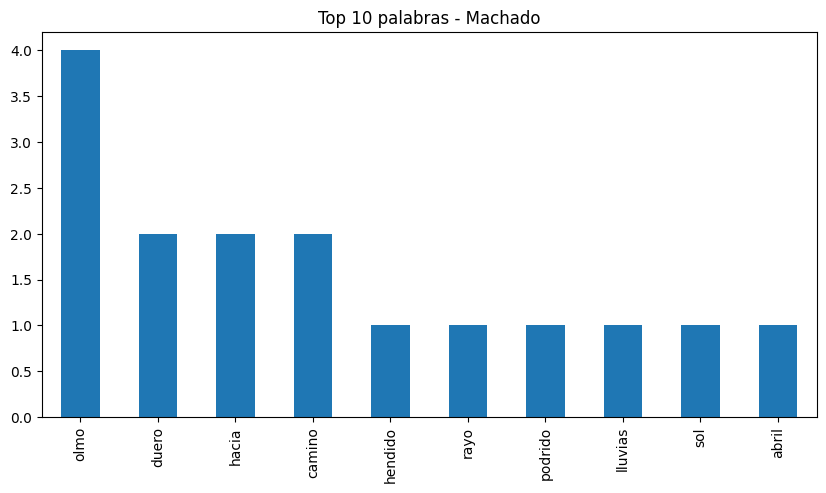

In [13]:
# Palabras más repetidas
plt.figure(figsize=(10,5))

freq_machado.head(10).plot(kind='bar')

plt.title('Top 10 palabras - Machado')

plt.show()

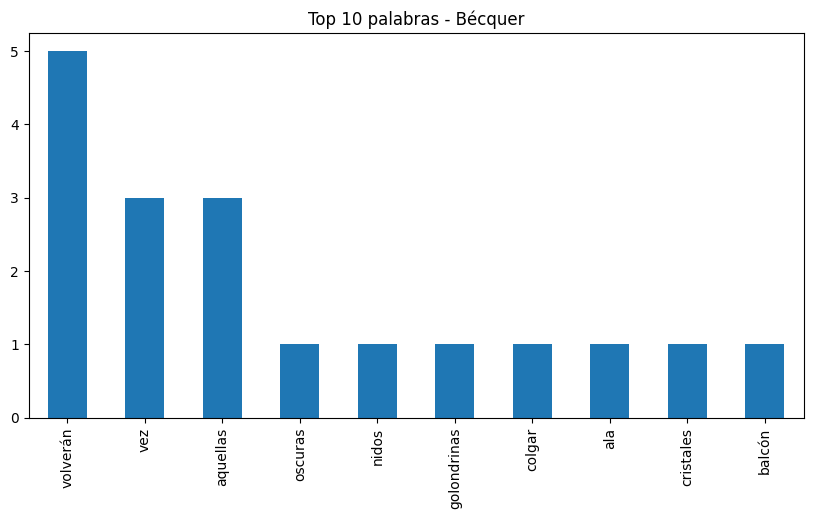

In [14]:
plt.figure(figsize=(10,5))

freq_becquer.head(10).plot(kind='bar')

plt.title('Top 10 palabras - Bécquer')

plt.show()

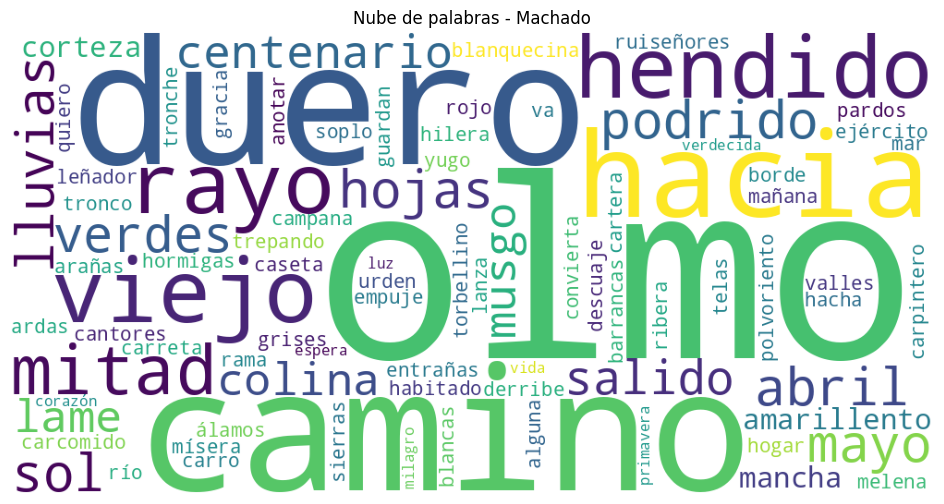

In [15]:
# Nube de palabras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(' '.join(tokens_machado))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Nube de palabras - Machado")
plt.show()

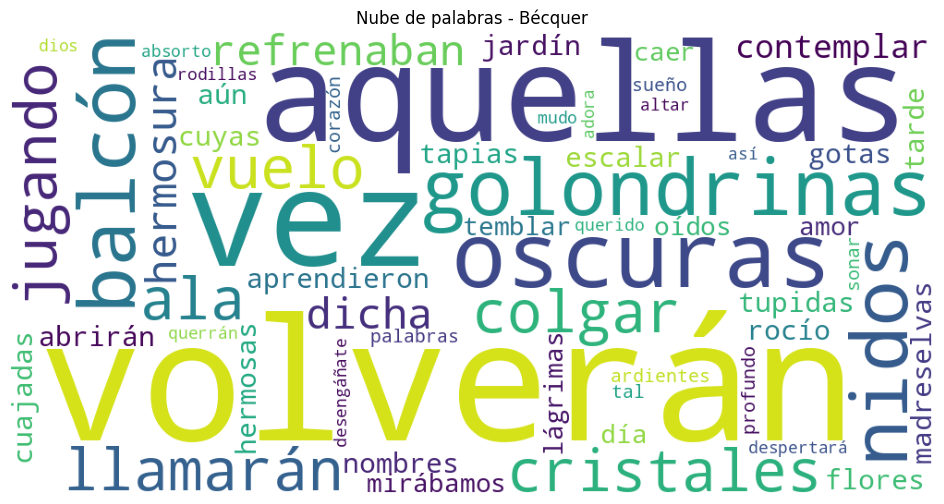

In [16]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(' '.join(tokens_becquer))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Nube de palabras - Bécquer")
plt.show()